# Polarimetry operations in nDspec

This notebook shows a few examples of how users can convert polarization states/models betweeen modulation curves, Stokes parameters, and polarization degree/angle. In nDspec, this is accomplished through the ```PolarimetryProduct``` operator.

In [1]:
import sys
import os
import numpy as np

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
from ndspec.Polarimetry import PolarimetryProduct

## Polarimetric states in Stokes parameters

In this first example, we will assume we know the Stokes parameters of our polarization state, and want to derive polarization degree and angle over some grid of testing bins. We begin with setting up a coarse model grid, defining Stokes I as a powerlaw of slope -2 and unity normalization, and some sort of exponential decay for Stokes Q and U over our chosen bins. 

In [2]:
#define our bin of whatever function we care about - for example, this might be the IXPE energy grid
test_bins = np.linspace(2,8,30)

gamma = -2.
norm = 1.
test_I = norm*test_bins**gamma

#elet us assume expoential decay for both Stokes U and Q because why not
test_U = norm*np.exp(-test_bins/test_bins[0])
test_Q = norm*np.exp(-test_bins/test_bins[-1])

Now that we have defined the arrays we want to use, we can initialize a ```PolarimetryProduct``` object by passing our grid of bins, and specifying that we will work in Stokes parameters.

We can then pass and plot the Stokes parameters we wish to use with the ```set_stokes``` and ```plot_stokes``` method:

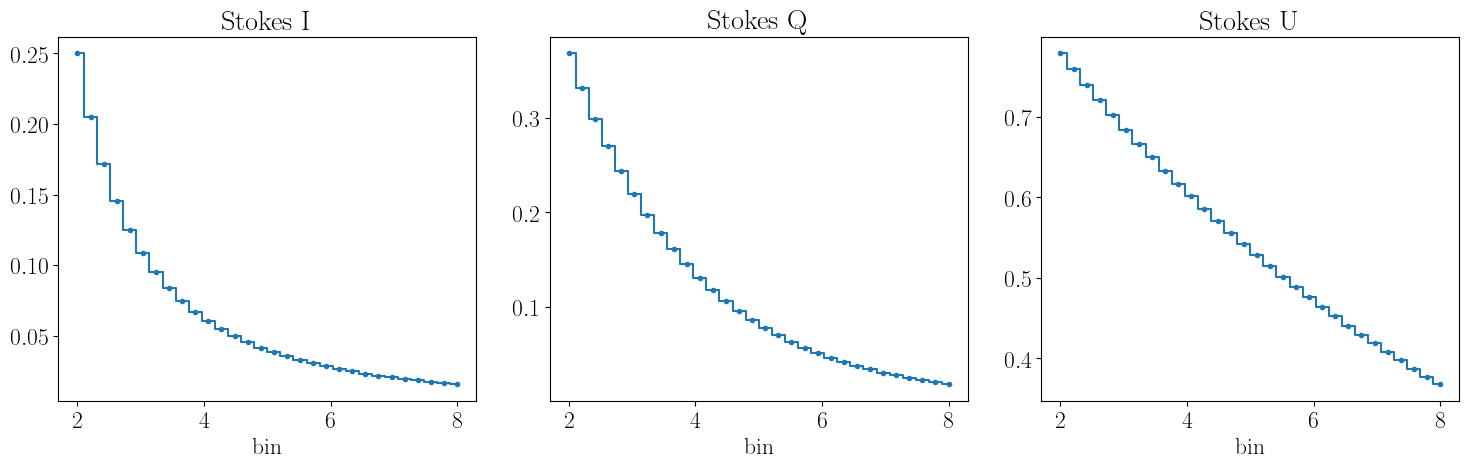

In [3]:
stokes_test = PolarimetryProduct(test_bins,input_type="stokes")
stokes_test.set_stokes(test_I,test_U,test_Q)

stokes_test.plot_stokes()

Now, converting and visualizing to polarization degree and angle is straightforward - all we need is to call the ```stokes_to_polarization``` method to compute the new arrays, which we can then plot with the ```plot_polarization_1d``` and ```plot_polarization_slice``` methods

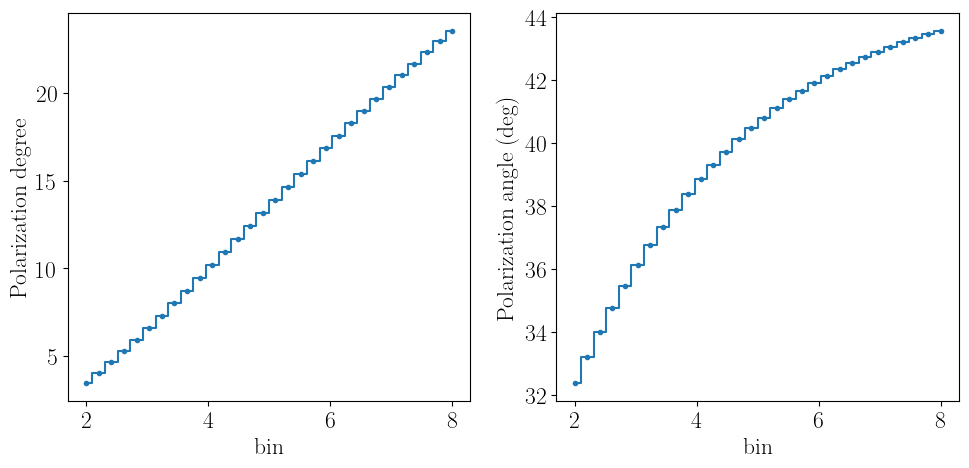

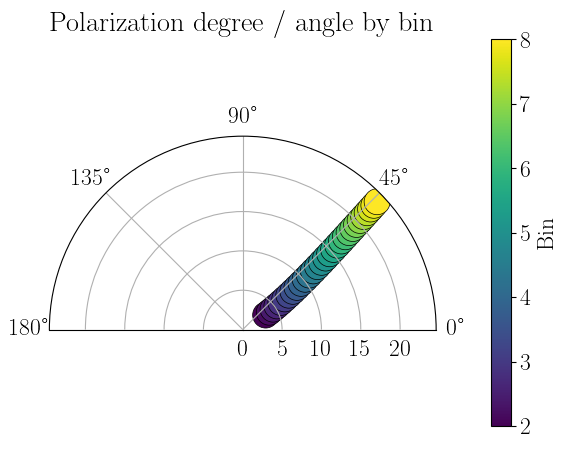

In [4]:
pol, ang = stokes_test.stokes_to_polarization()

stokes_test.plot_polarization_1d()
stokes_test.plot_polarization_slice()

In addition, we can apply an arbitrary rotation to the Stokes parameters, and then re-compute and re-plot the polarization degree and angle, using the ```rotate_polarization``` method:

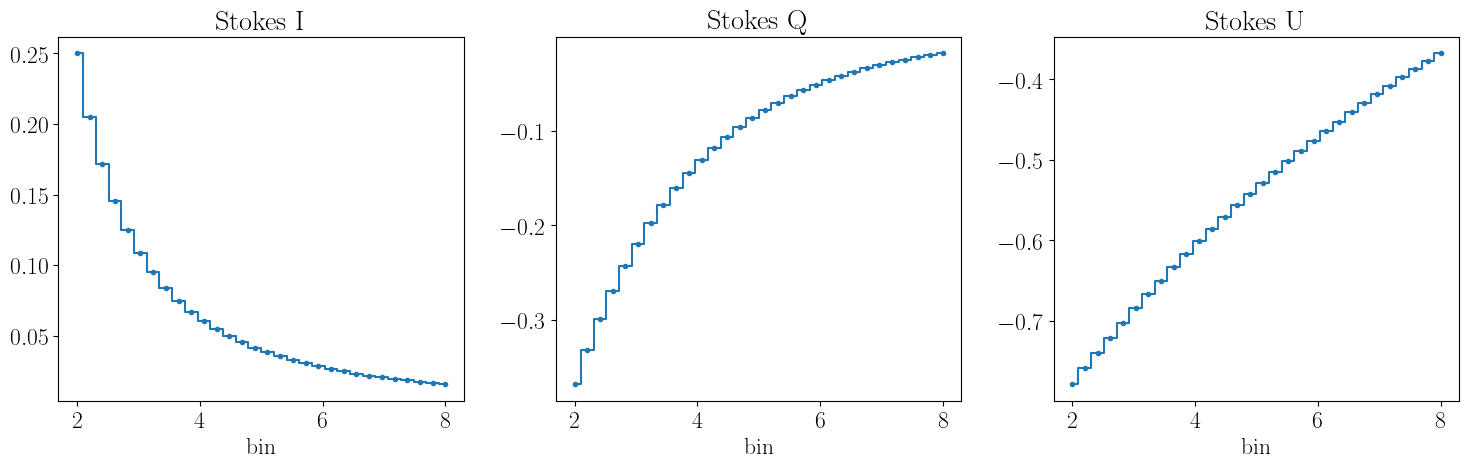

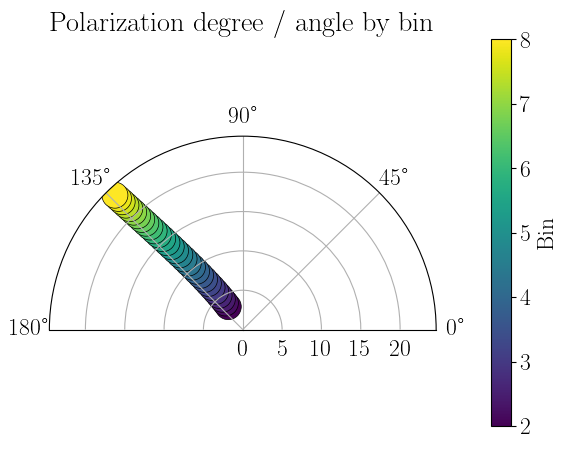

In [5]:
new_stokes = stokes_test.rotate_polarization(90)

stokes_test.plot_stokes()

pol, ang = stokes_test.stokes_to_polarization()
stokes_test.plot_polarization_slice()

Finally, given the Stokes parameters, we can define a grid of modulation angles, an array of modulation factors per bin, and derive the modulation curve using the ```stokes_to_modulation``` method.

We can then plot the modulation curve, either in one or two dimensions. Both use the ```plot_modulation_method```; by default this method produces a two-dimensional plot, but we can create a one-dimensional plots by selecting bins we only care about as well: 

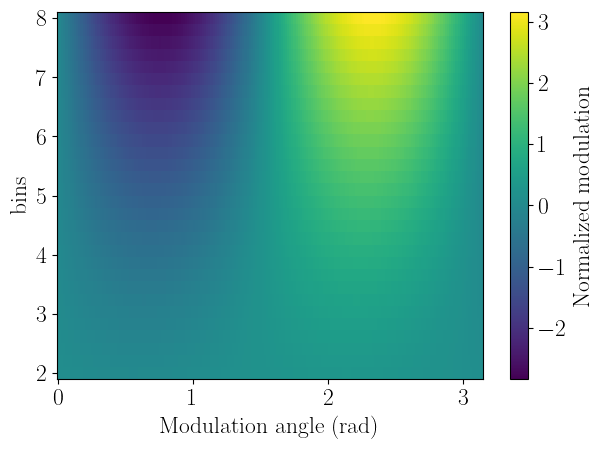

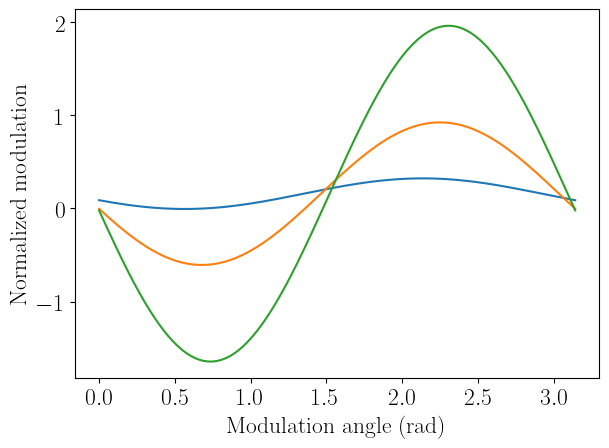

In [6]:
angles = np.linspace(0,np.pi,200)
modfact = np.linspace(0.3,0.8,len(test_bins))

stokes_test.set_modulation_factor(modfact)
stokes_test.set_modulation_angles(angles)

mod = stokes_test.stokes_to_modulation()

stokes_test.plot_modulation()
stokes_test.plot_modulation(bin_index=[0,10,20])

## Polarimetric states in polar coordinates

Working from polarization degree and angle is analogous to the previous case; note however that we still need to define the Stokes I parameter, as it is required to re-normalize all the quantities when converting to and from polar coordinates.

In this case, we will assume our polarization degree and angle are both constant over all of our bins, and calculate what the corresponding Stokes parameters and modulation curve are.

In [7]:
test_bins = np.linspace(1,10,20)

gamma = -2.
norm = 1.
test_I = norm*test_bins**gamma

#5% polarization at 30 degrees across all bins
frac = 0.05
deg = 30.

test_frac = np.linspace(frac,frac,len(test_bins))
test_deg = np.linspace(deg,deg,len(test_bins))

Like before, we create our object, specifying we are working in polar coordinates this time, and then set and plot our input arrays with the ```set_polarization``` and ```plot_polarization...``` methods:

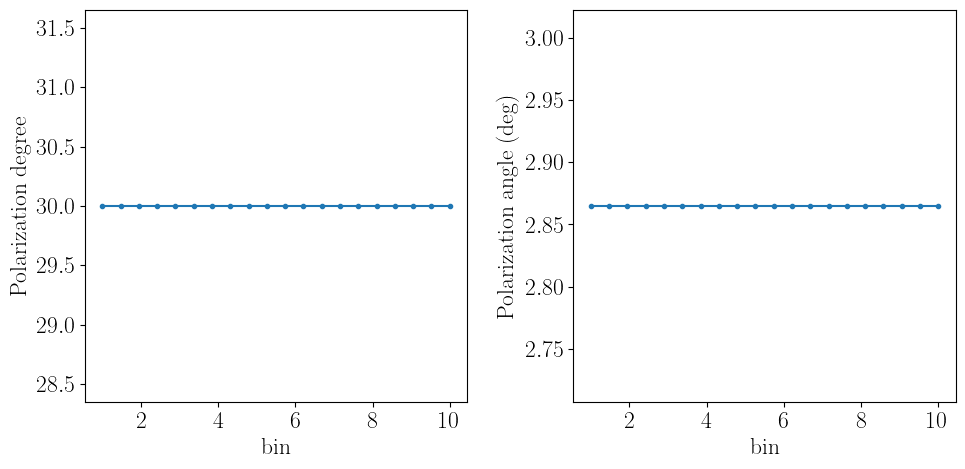

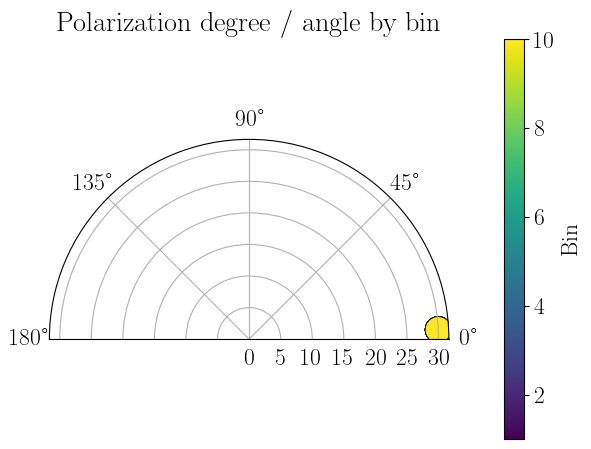

In [8]:
polar_test = PolarimetryProduct(test_bins,input_type="polarization")

polar_test.set_polarization(test_I,test_deg,test_frac)
polar_test.plot_polarization_1d()
polar_test.plot_polarization_slice()

Converting to Stokes parameters is analogous to the first example, we simply have to call ```polarization_to_stokes```, which computes the parameter we can then use for plotting.

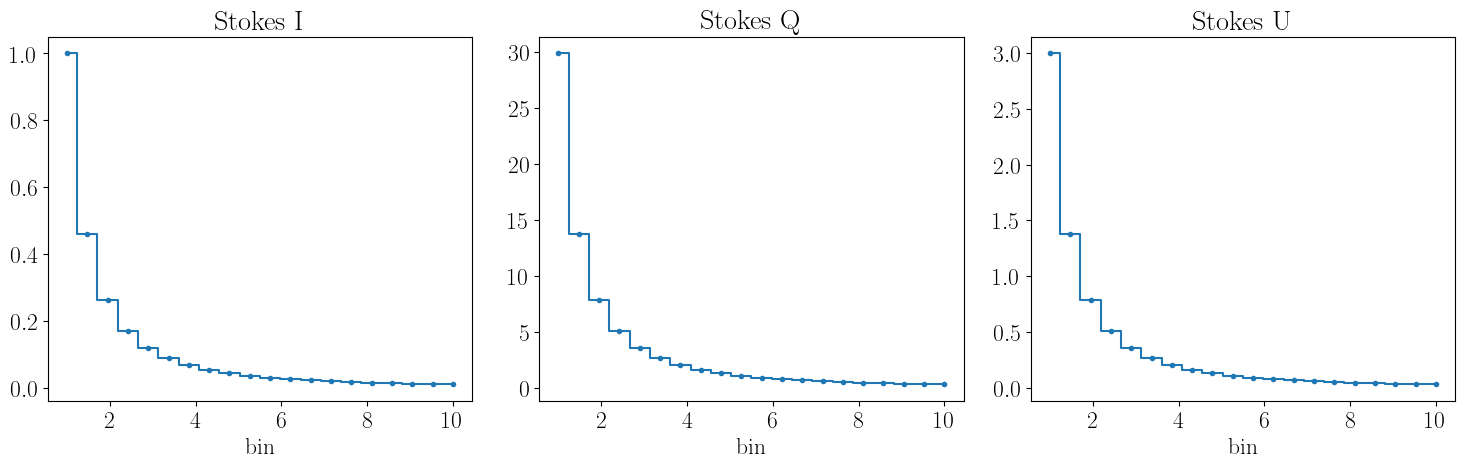

In [9]:
polar_I, polar_U, polar_Q = polar_test.polarization_to_stokes()

polar_test.plot_stokes()

Calculating the modulation curve is also analogous: we define a modulation angle grid and a set of modulatio factor, pass them to the object, and then compute the modulation curve with the ```polarization_to_modulation``` method:

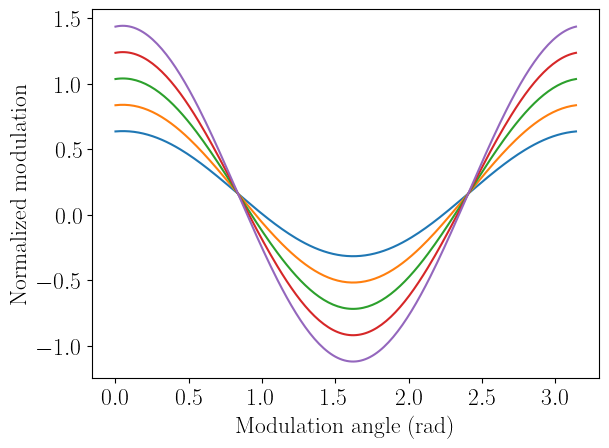

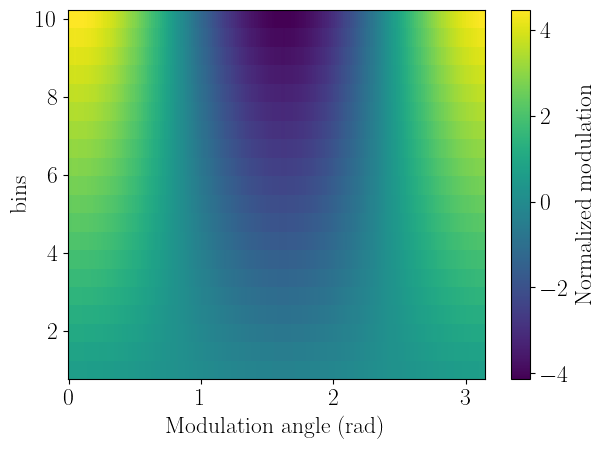

In [10]:
angles = np.linspace(0,np.pi,200)
modfact = np.linspace(0.1,0.9,len(test_bins))

polar_test.set_modulation_factor(modfact)
polar_test.set_modulation_angles(angles)

mod = polar_test.polarization_to_modulation()

polar_test.plot_modulation(bin_index=[0,1,2,3,4])
polar_test.plot_modulation()